In [ ]:
%load_ext autoreload

%autoreload 2

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import random
import scipy

sc.set_figure_params(dpi=80)
plt.rcParams["axes.grid"] = False

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))

from general_utils import ismember, grep, array_to_csr_matrix, array_to_edges
from anndata_utils import query_region, random_adata_subset, filter_coordinates
from plotting_functions import plot_individual_category, plot_gene, make_density_map, get_custom_legend_patches, get_custom_legend_circles


/data1/lowes/reyesj3/ManuscriptData_20260305/transcriptomics/notebooks/../../utils/plotting_functions.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Import data: embedding of TME cells (excluding lymph nodes and tissue regions farther than 200um from an epithelial cell)

In [ ]:
adata = sc.read_h5ad("../data/Reyes_Xenium_TIER_Krasi_SUBSET_Dissected_TME__annotated.h5ad")
milo_output_file = '../data/Reyes_Xenium_TIER_Krasi_SUBSET_Dissected_TME__milo.RData'


/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


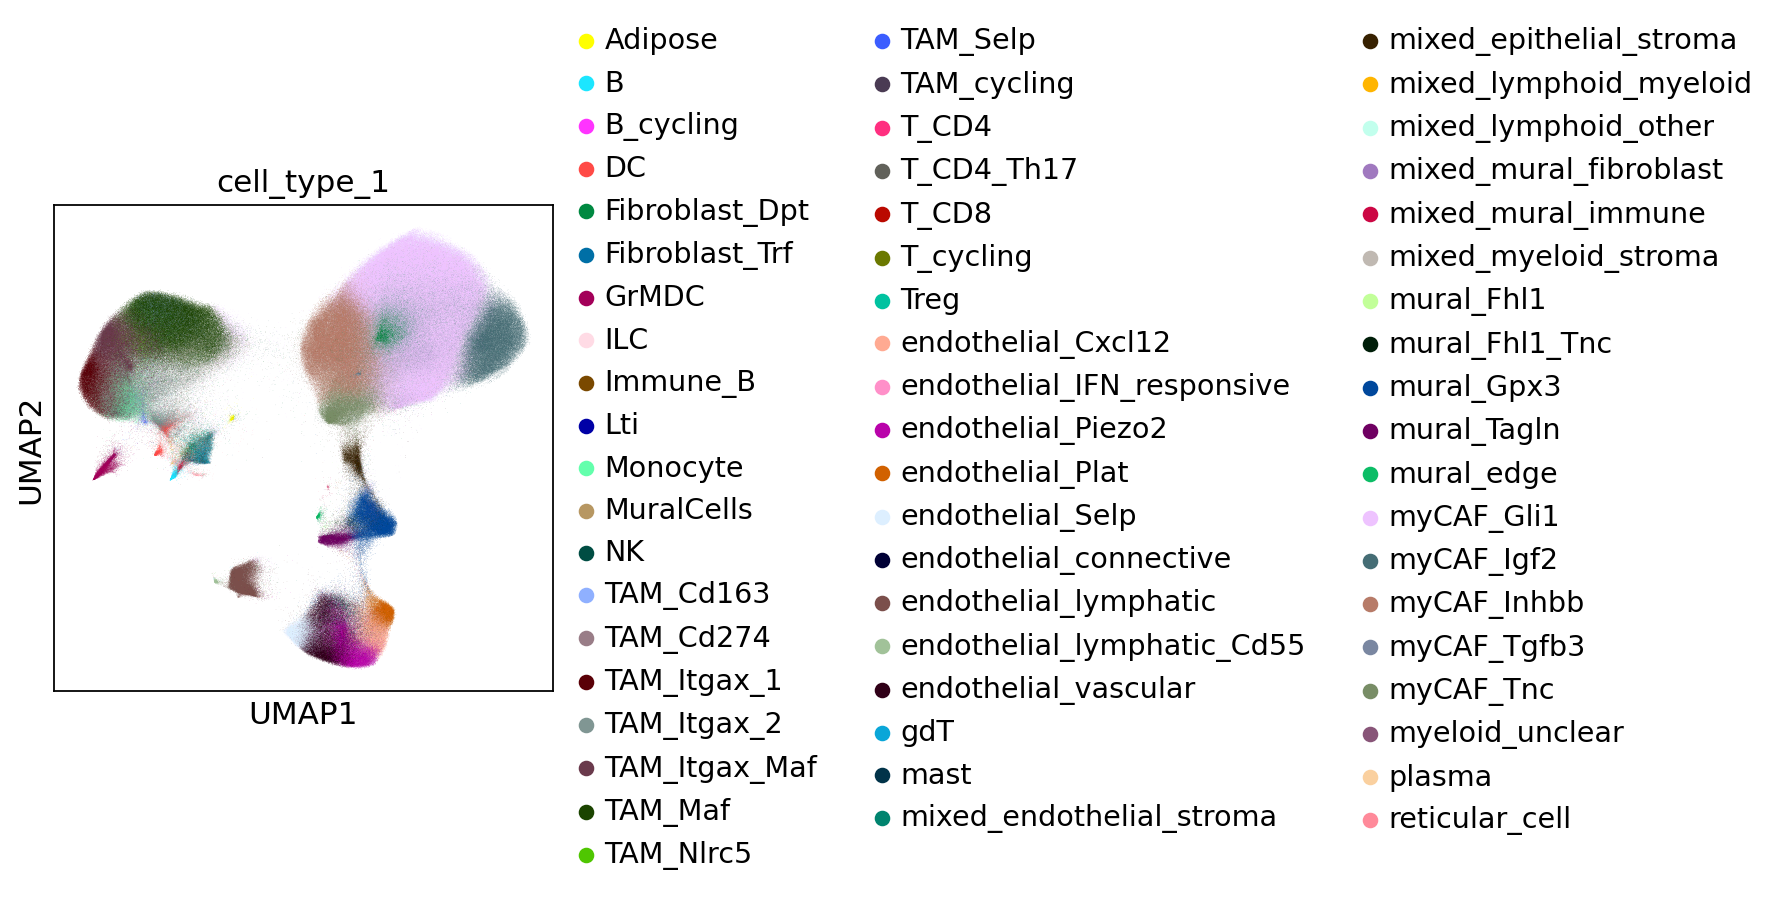

In [ ]:
sc.pl.umap(adata, color='cell_type_1')

### Milo analysis in R

In [ ]:
#import rpy2
#from rpy2.robjects import pandas2ri
#import rpy2.robjects as robjects

#%load_ext rpy2.ipython

In [ ]:
def read_R_data_frame(r_command):
    my_data_frame = robjects.r(r_command)
    df = pd.DataFrame.from_dict({ key : np.asarray(my_data_frame.rx2(key)) for key in my_data_frame.names })
    return(df)

In [ ]:
sources, targets = array_to_edges(adata.obsm['indices'])
X_pca = adata.obsm["X_pca"].copy()
obs_names = adata.obs_names.to_numpy()
obs = adata.obs.copy()

The code below constructs a Milo object from precomputed adjacency matrix. This is the final choice

In [ ]:
%%R -i X_pca,obs,obs_names,sources,targets,milo_output_file

library(miloR)
library(Matrix)
library(SingleCellExperiment)

if(file.exists(milo_output_file)){
    load(milo_output_file)
}else{
    knn_sparse <- sparseMatrix(i=sources + 1, j=targets + 1,x=rep(1, length(sources)))
    precomputed_knn <- buildFromAdjacency(knn_sparse, is.binary=TRUE)
    SCE <- SingleCellExperiment(
        assays=list(counts=Matrix(0L, nrow=1, ncol=nrow(X_pca))),
        reducedDims=SimpleList("PCA"=X_pca)
    )
    milo <- Milo(SCE)
    graph(milo) <- precomputed_knn@graph[[1]]
    milo <- makeNhoods(milo, prop = 0.01, k = 30, d=dim(reducedDim(milo))[2], refined = TRUE, reduced_dims = "PCA")
    milo@.k=30
    milo <- countCells(milo, meta.data = obs, sample="slide_id")
    milo <- calcNhoodDistance(milo, d=30)
    milo <- buildNhoodGraph(milo)
    save(milo, file = milo_output_file)
}


In [ ]:
%%R
design_df <- obs[,c("slide_id", "condition")]
design_df <- design_df[!duplicated(design_df),]
rownames(design_df) <- design_df$slide_id
design_df

da_results <- testNhoods(milo, design = ~ condition, design.df = design_df)

In [ ]:
%%R
library(anndata)
adata <- AnnData(X = nhoods(milo))
adata$obs_names <- obs_names
adata$var <- da_results
adata$obs <- obs
write_h5ad(adata, gsub(".RData", ".h5ad", milo_output_file))

#### Continue Milo analysis in python

Read Milo object

In [ ]:
adata_milo = sc.read_h5ad('../data/Reyes_Xenium_TIER_Krasi_SUBSET_Dissected_TME__milo.h5ad')

#### Classify spatial neighborhoods

Because Milo results are only on TME, I import the entire Xenium object, alongside the spatial neighborhoods. I then transfer the cell type annotations from the general object into the spatial neighborhood adata.

In [ ]:
adata_neighborhood = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__spatial_neighborhood.h5ad")
adata_obs = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__annotated.h5ad")
adata_neighborhood.obs = adata_obs.obs.copy()

Subset spatial neighborhood graph to include only epithelial neighborhoods and TME cells in the samples that were subjected to Milo analysis

In [ ]:
# These are the valid neighbor cells (from milo)
valid_rows = ismember(adata_neighborhood.obs_names, adata.obs_names)[1]

# These are the valid anchor cells (epithelial cells from milo analysis samples)
cell_type_filter = ismember(adata_neighborhood.obs['cell_type_0'], ['Epithelial'])[1]
slide_filter = ismember(adata_neighborhood.obs['slide_id'], np.unique(adata.obs['slide_id']))[1]
valid_columns = np.logical_and(cell_type_filter, slide_filter)

spatial_neighborhood = adata_neighborhood.obsp['spatial_neighborhood'][valid_rows,:].copy()[:,valid_columns].copy()

Verify that cell_ids are identical between adata and adata_neighborhood after subsetting

In [ ]:
np.mean([x == y for x,y in zip(adata.obs_names, adata_neighborhood.obs_names[valid_rows])])

1.0

Count cells of a particular target type in cellular communities (as defined by milo)

In [ ]:
def get_cell_type_count(cell_type_annotation, target_cell_types, spatial_neighborhood):
    selected_columns = ismember(cell_type_annotation, target_cell_types)[1]
    total_cells_per_neighborhood = np.ravel(spatial_neighborhood.sum(axis=1))
    query_cells_per_neighborhood = np.ravel(spatial_neighborhood[:,selected_columns].sum(axis=1))
    frequency_in_dataset = np.mean(selected_columns)
    return(query_cells_per_neighborhood, total_cells_per_neighborhood, frequency_in_dataset)

def log_cell_type_enrichment_neighborhoods(cell_id, neighborhood_id, cell_type_annotation, target_cell_types, spatial_neighborhood):
    redundant_neighborhood = spatial_neighborhood[sources,:].copy()
    query_neighbors, total_neighbors, frequency_in_dataset = get_cell_type_count(cell_type_annotation, target_cell_types, redundant_neighborhood)
    query_per_milo_neighborhood = pd.Series(query_neighbors).groupby(targets).agg('sum').to_numpy()
    total_per_milo_neighborhood = pd.Series(total_neighbors).groupby(targets).agg('sum').to_numpy()
    frequency_in_neighborhood = query_per_milo_neighborhood / total_per_milo_neighborhood
    zero_freq = frequency_in_neighborhood == 0
    min_nonzero_freq = np.min(frequency_in_neighborhood[np.logical_not(zero_freq)])
    frequency_in_neighborhood += min_nonzero_freq
    frequency_in_neighborhood[frequency_in_neighborhood > 1] = 1
    log_ratio = np.log(frequency_in_neighborhood / frequency_in_dataset) / np.log(2)
    return(log_ratio)

In [ ]:
sources, targets = adata_milo.X.nonzero()

cell_type_annotation = adata_neighborhood.obs['cell_type_1'][valid_columns]
target_cell_types = ['progenitor1', 'progenitor2']
progenitor_milo_enrichment = log_cell_type_enrichment_neighborhoods(sources, targets, cell_type_annotation, target_cell_types, spatial_neighborhood)
target_cell_types = ['gastric', 'gastric_chief', 'gastric_pit', 'gastric_Ccn2']
gastric_milo_enrichment = log_cell_type_enrichment_neighborhoods(sources, targets, cell_type_annotation, target_cell_types, spatial_neighborhood)


In [ ]:
adata_milo.var['progenitor_milo_enrichment'] = progenitor_milo_enrichment.copy()
adata_milo.var['gastric_milo_enrichment'] = gastric_milo_enrichment.copy()


#### Annotate milo clusters by cell type 1

In [ ]:
def most_common(v):
    values, counts = np.unique(v, return_counts=True)
    ind = np.argmax(counts)
    return(values[ind])  # prints the most frequent element

def enrichment_of_top_value(v):
    values, counts = np.unique(v, return_counts=True)
    counts = np.sort(counts)[::-1]
    if(len(counts) > 1):
        result = counts[0] / counts[1]
    else:
        # Default enrichment when there is only one cell type in the series
        result = 10
    return(result)
    

Transfer cell type annotations from main anndata object into milo anndata object

In [ ]:
adata_milo.obs['cell_type_1'] = adata[adata_milo.obs_names,:].obs['cell_type_1']
adata_milo.obs['cell_type_0'] = adata[adata_milo.obs_names,:].obs['cell_type_0']

In [ ]:
cell_type_temp = adata_milo.obs['cell_type_0'].to_numpy()
cell_type_temp[ismember(cell_type_temp, ['Endothelial_Vascular', 'Endothelial_Lymphatic'])[1]] = 'Endothelial'
cell_type_temp[ismember(cell_type_temp, ['Immune_B', 'Immune_TNKILC'])[1]] = 'Immune_Lymphoid'

adata_milo.obs['cell_type_0'] = cell_type_temp.copy()

Calculate homogeneity score: the enrichment of top cell type in neighborhood, relative to the second most-frequent cell type

In [ ]:
df = pd.DataFrame({'nhood': targets, 'cell_id': sources})
df['cell_type_1'] = adata_milo.obs['cell_type_1'].to_numpy()[df['cell_id'].to_numpy()]
df['cell_type_0'] = adata_milo.obs['cell_type_0'].to_numpy()[df['cell_id'].to_numpy()]
adata_milo.var['cell_type_1'] = df.groupby('nhood').agg(lambda x: most_common(x))['cell_type_1'].to_numpy()
adata_milo.var['cell_type_0'] = df.groupby('nhood').agg(lambda x: most_common(x))['cell_type_0'].to_numpy()
adata_milo.var['homogeneity_score'] = df.loc[:,['nhood', 'cell_type_0']].groupby('nhood').agg(
    lambda x: enrichment_of_top_value(x))['cell_type_0'].to_numpy()

~30% of Milo neighborhoods are composed of a single cell type

In [ ]:
print(np.mean(adata_milo.var['homogeneity_score'] == 10))

0.28276589334136787


Most Milo neihghborhoods are dominated by a single cell type

Text(0, 0.5, 'Density')

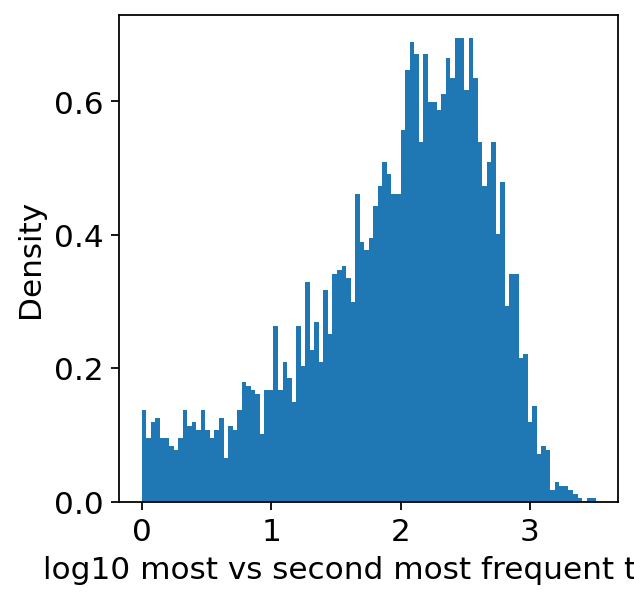

In [ ]:
h = plt.hist(np.log(adata_milo.var['homogeneity_score'][adata_milo.var['homogeneity_score'] != 10])/np.log(10), 100, density = True)
plt.grid(False)
plt.xlabel('log10 most vs second most frequent type')
plt.ylabel('Density')

Rare Milo neighborhoods represent mixtures of distinct coarse cell types. In these neighborhoods, there is not a big difference between the top two cell types in the neighborhood

In [ ]:
adata_milo.var['homogeneity_score'][np.where(np.logical_and(adata_milo.var['cell_type_0'] == 'Fibroblast', adata_milo.var['cell_type_1'] == 'TAM_Maf'))[0]]

1100    1.623494
3139    1.002747
3203    1.037815
Name: homogeneity_score, dtype: float64

We exclude the 5% neighborhoods with lowest homogeneity score (1st vs 2nd dominant cell types in Milo neighborhood)

In [ ]:
homogeneity_threshold = np.quantile(adata_milo.var['homogeneity_score'][adata_milo.var['homogeneity_score'] != 10], [0.05])[0]
print(homogeneity_threshold)

2.8955223880597014


Plot for manuscript: each dot is a milo neighborhood, the dot size is proportional to SpatialFDR, colors represent the enrichment of progenitor-like cells in the neighborhood

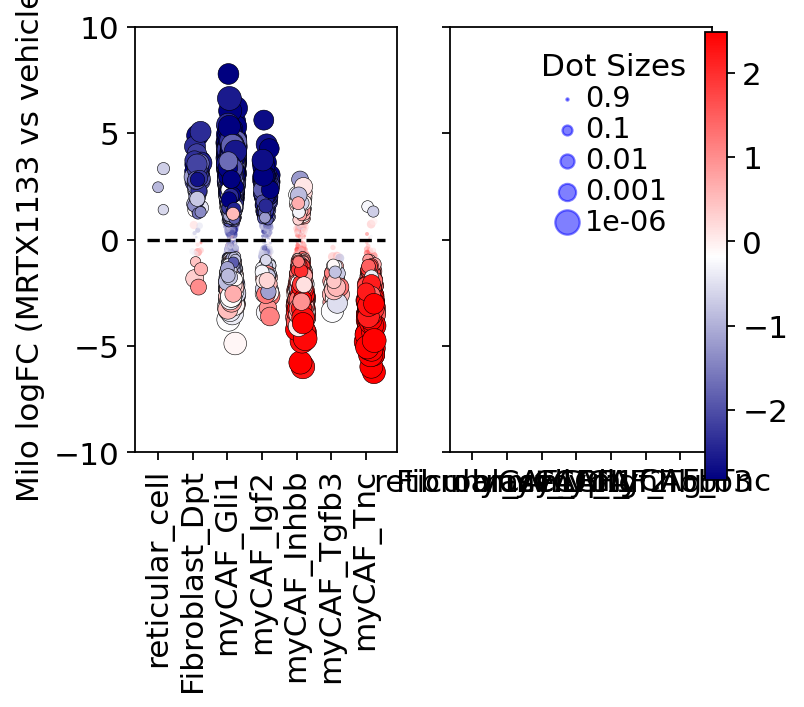

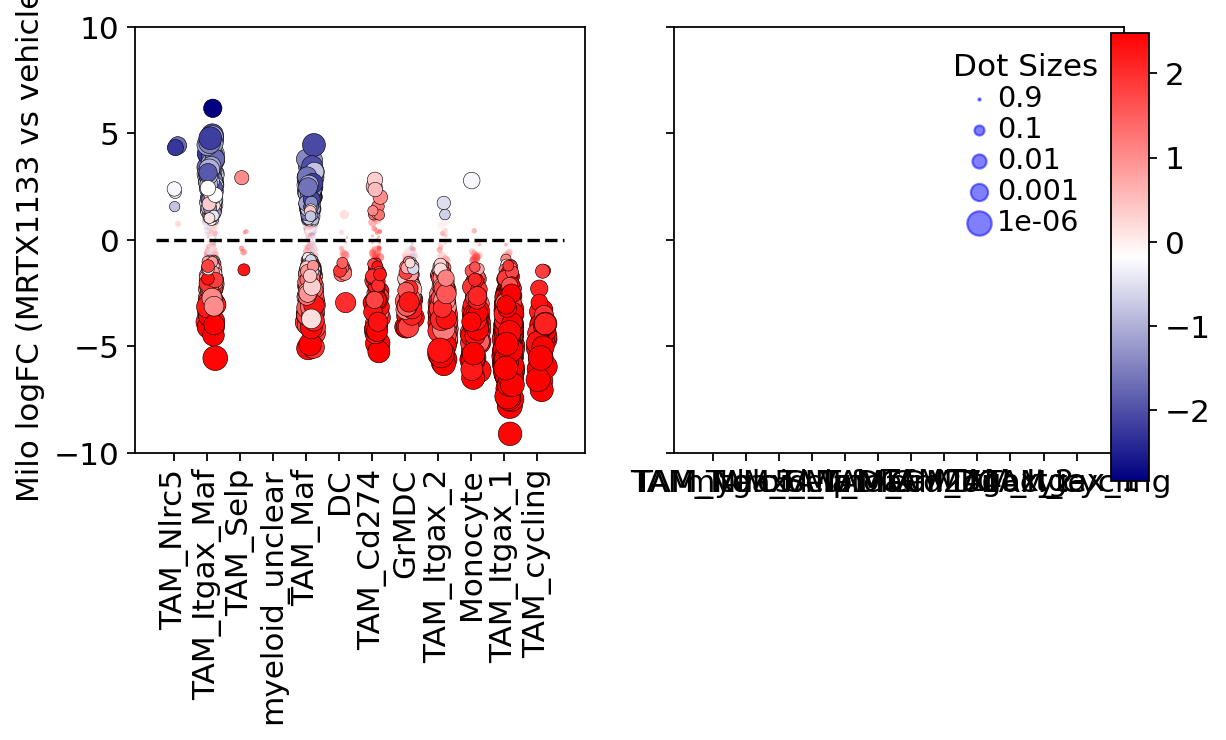

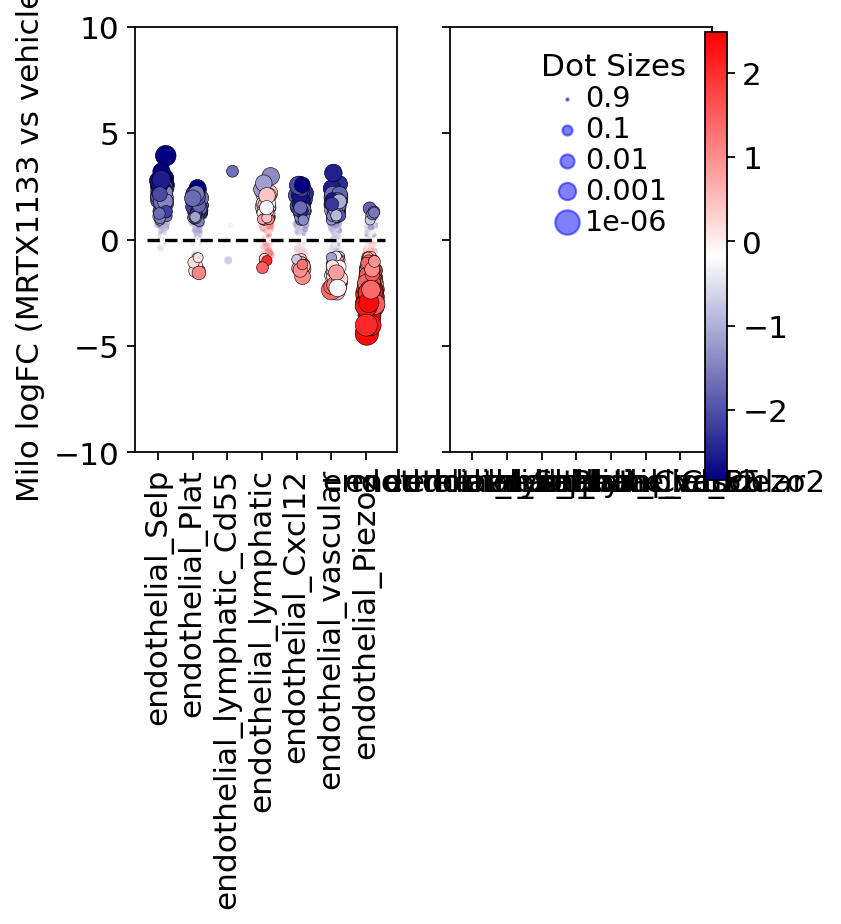

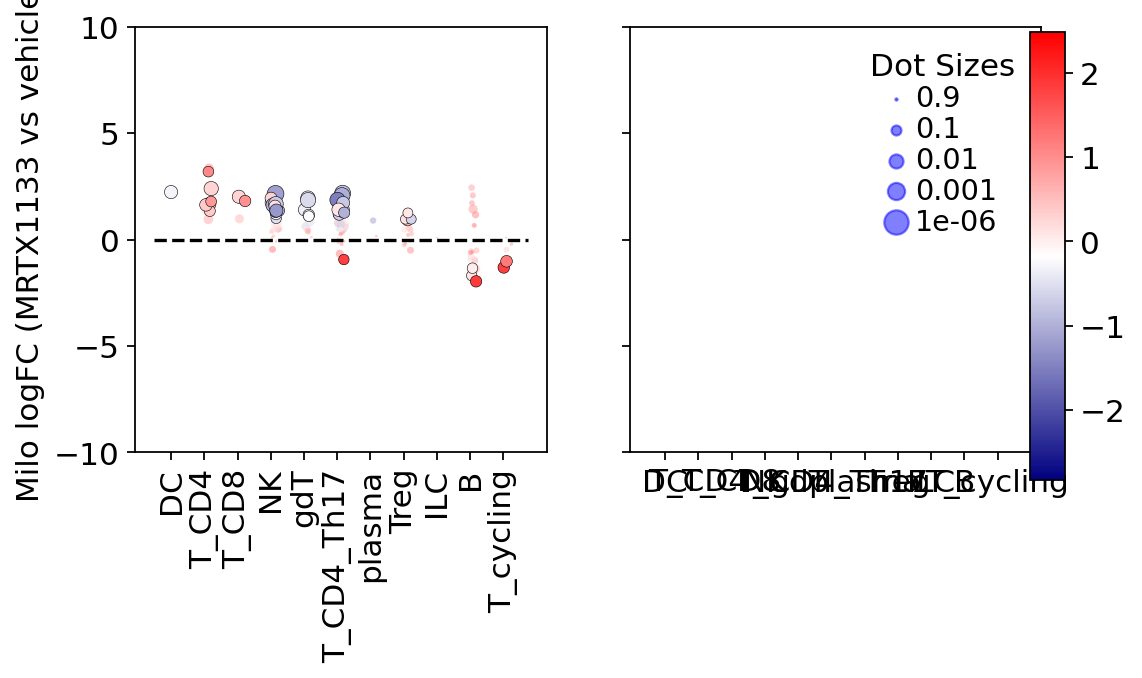

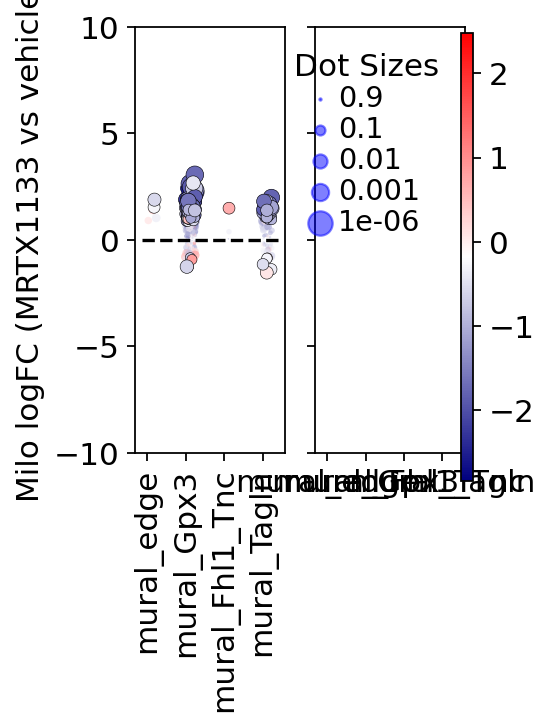

In [ ]:
cmap0 = matplotlib.colors.LinearSegmentedColormap.from_list(
        'blue2red', ['navy', 'white', 'red'])

selected_compartments = ['Fibroblast', 'Immune_Myeloid', 'Endothelial', 'Immune_Lymphoid', 'MuralCells']

vmin = np.quantile(adata_milo.var['progenitor_milo_enrichment'], 0.05)
vmax = np.quantile(adata_milo.var['progenitor_milo_enrichment'], 0.95)

for my_compartment in selected_compartments:
    df = adata_milo[:,adata_milo.var['cell_type_0'] == my_compartment].var.copy()
    df = df.loc[df['homogeneity_score'] > homogeneity_threshold,:].copy()
    
    cell_type_order = df.loc[:,['logFC', 'cell_type_1']].groupby('cell_type_1').agg('mean').sort_values(by = 'logFC')
    df['ordering'] = ismember(df['cell_type_1'], cell_type_order.index.to_numpy())[0]
    df['point_size'] = -np.log(df['SpatialFDR'])/np.log(10) * 20
    df['randomness'] = [np.random.rand() * 0.25 for x in range(df.shape[0])]
    df['xval'] = df['ordering'] + df['randomness']

    num_cell_states = len(np.unique(df['ordering']))
    f, ax = plt.subplots(1,2,figsize = [num_cell_states*0.66,3.5], sharex = True, sharey = True)
    ax[0].scatter(
        df['xval'], -df['logFC'], s = df['point_size'], 
        c=df['progenitor_milo_enrichment'], cmap = cmap0, 
        edgecolor='None',
        rasterized = True,
        vmin = vmin, vmax = vmax, alpha = 0.5)
    
    sub_neighborhoods = df['SpatialFDR'] < 0.1
    im = ax[0].scatter(
        df['xval'][sub_neighborhoods], 
        -df['logFC'][sub_neighborhoods], 
        s = df['point_size'][sub_neighborhoods],
        c=df['progenitor_milo_enrichment'][sub_neighborhoods],
        cmap = cmap0, vmin = vmin, vmax = vmax,
        linewidth = 0.25,
        rasterized = True,
        edgecolor='k')
    
    ax[0].grid(False)
    ax[0].plot(ax[0].get_xlim(), [0,0], 'k--')
    _ = ax[0].set_xticks(range(cell_type_order.shape[0]), labels=cell_type_order.index.to_numpy(), rotation = 90)
    ax[0].set_ylabel('Milo logFC (MRTX1133 vs vehicle)')
    ax[0].set_ylim([-10, 10])
    
    labels = [0.9, 0.1, 0.01, 0.001, 0.000001]
    sizes = [-np.log(x)/np.log(10) * 20 for x in labels]
    
    # Create the scatter plot - we plot empty data, just to generate legend handles
    for size, label in zip(sizes, labels):
        ax[1].scatter([], [], s=size, label=label, color='blue', alpha=0.5)
    
    # Create legend with size-based handles
    ax[1].legend(scatterpoints=1, frameon=False, labelspacing=0.1, title='Dot Sizes')

    cax = f.add_axes([0.95, 0.1, 0.03, 0.8])  # [left, bottom, width, height]
    cbar = f.colorbar(im, cax=cax)


Define progenitor enriched milo neighborhoods based on the degree of enrichment of progenitor-like cells or gastric-like cells in their spatial communities. Progenitor enriched neighborhoods are in the lower right quadrant

Text(0, 0.5, 'Gastric milo enrichment')

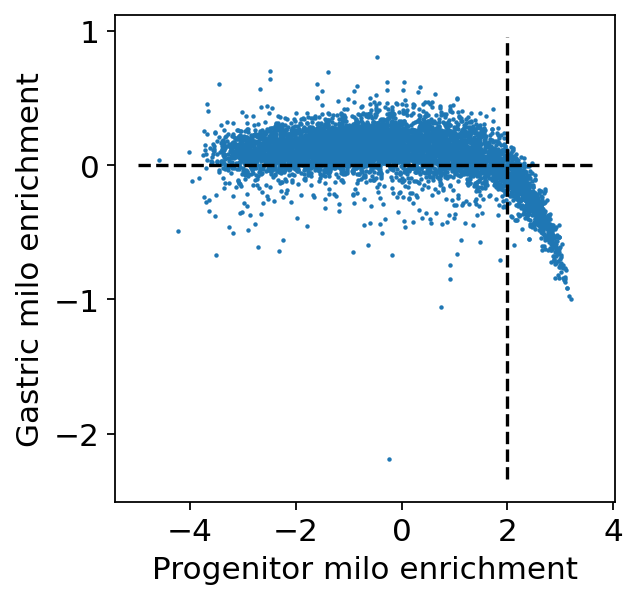

In [ ]:
f = plt.figure()
plt.scatter(progenitor_milo_enrichment, gastric_milo_enrichment, s=1)
plt.plot([2,2], plt.gca().get_ylim(), 'k--')
plt.plot(plt.gca().get_xlim(), [0,0], 'k--')
plt.xlabel('Progenitor milo enrichment')
plt.ylabel('Gastric milo enrichment')

In [ ]:
adata_milo.var['progenitor_enrichment'] = progenitor_milo_enrichment
adata_milo.var['progenitor_neighborhood'] = np.logical_and(progenitor_milo_enrichment > 2, gastric_milo_enrichment < 0)

In [ ]:
adata_milo.var.columns

Index(['logFC', 'logCPM', 'F', 'PValue', 'FDR', 'Nhood', 'SpatialFDR',
       'cell_type_1', 'cell_type_0', 'homogeneity_score',
       'progenitor_milo_enrichment', 'gastric_milo_enrichment',
       'progenitor_enrichment', 'progenitor_neighborhood'],
      dtype='object')

In [ ]:
df = adata_milo.var[['progenitor_neighborhood', 'progenitor_enrichment', 'logFC', 'SpatialFDR']]
df['logFC'] = -df['logFC']

/data/lowe/reyesj3/repositories/temp/ipykernel_88597/993737076.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['logFC'] = -df['logFC']


Text(0, 0.5, 'Milo logFC\n(Kras inhibitor vs vehicle)')

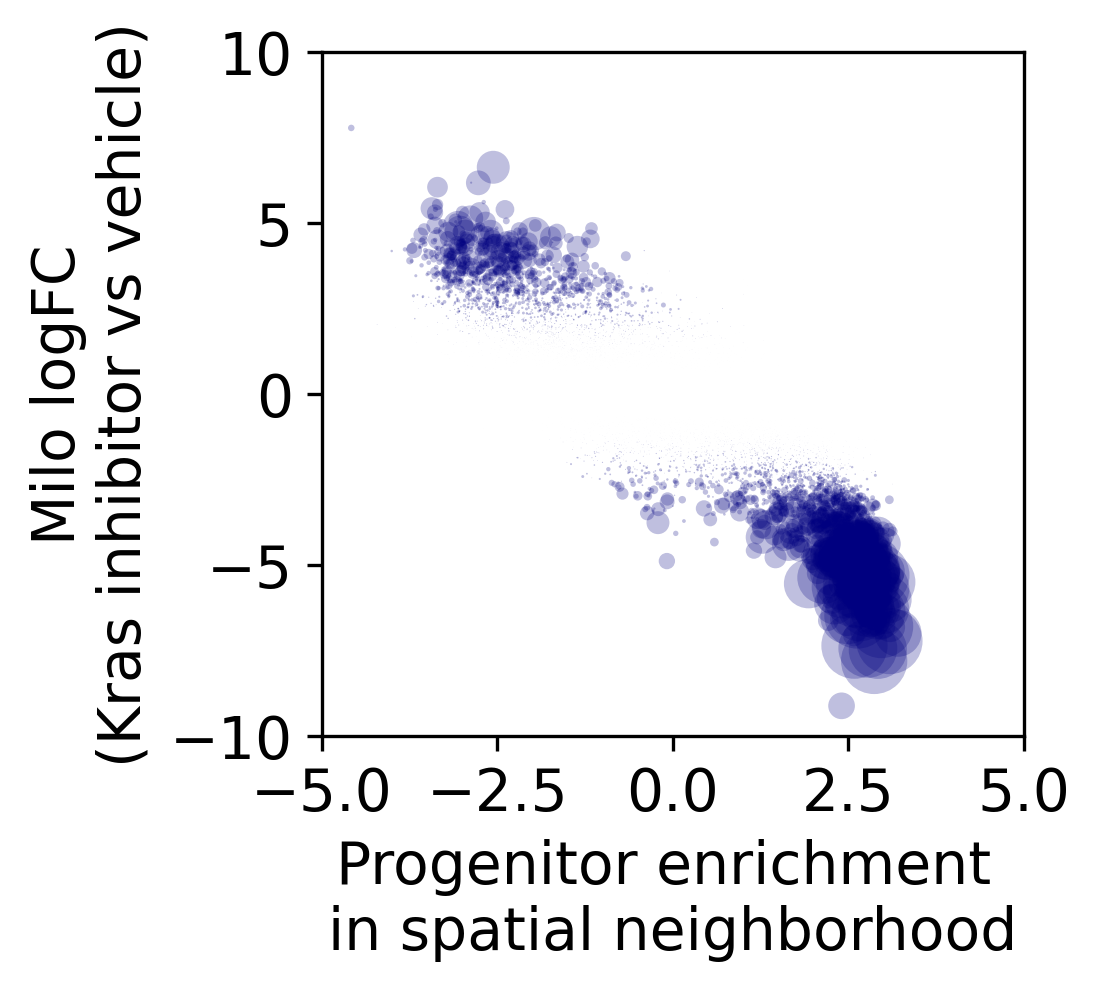

In [ ]:
plt.figure(figsize = [3,3], dpi = 150)

plt.scatter(df['progenitor_enrichment'], df['logFC'], s = (1/df['SpatialFDR'])/10000, alpha = 0.25, edgecolor='None', facecolor='navy')
plt.xlim([-5,5])
plt.ylim([-10,10])
plt.grid(False)
plt.xlabel("Progenitor enrichment \nin spatial neighborhood")
plt.ylabel("Milo logFC\n(Kras inhibitor vs vehicle)")

#### Plot contours in UMAP representation

Plot cells enriched in the vicinity of progenitor-like premalignant cells (purple), and density of cells after KRAS inhibitor 

In [ ]:
progenitor_niches = np.logical_and(progenitor_milo_enrichment > 2, gastric_milo_enrichment < 0)
cells_in_progenitor_niches = sources[ismember(targets, np.where(progenitor_niches)[0])[1]]
cells_in_krasi = adata.obs['condition'] == 'K2_MRTX1133'

depleted_neighborhoods = np.where(np.logical_and(adata_milo.var['SpatialFDR'] < 0.001, adata_milo.var['logFC'] > 0))[0]
cells_in_depleted_neighborhoods = sources[ismember(targets,depleted_neighborhoods)[1]]

enriched_neighborhoods = np.where(np.logical_and(adata_milo.var['SpatialFDR'] < 0.001, adata_milo.var['logFC'] < 0))[0]
cells_in_enriched_neighborhoods = sources[ismember(targets,enriched_neighborhoods)[1]]

In [ ]:
adata_random1 = random_adata_subset(adata, scaling=0.01)
adata_random2 = random_adata_subset(adata, scaling=0.25)

<Figure size 400x400 with 0 Axes>

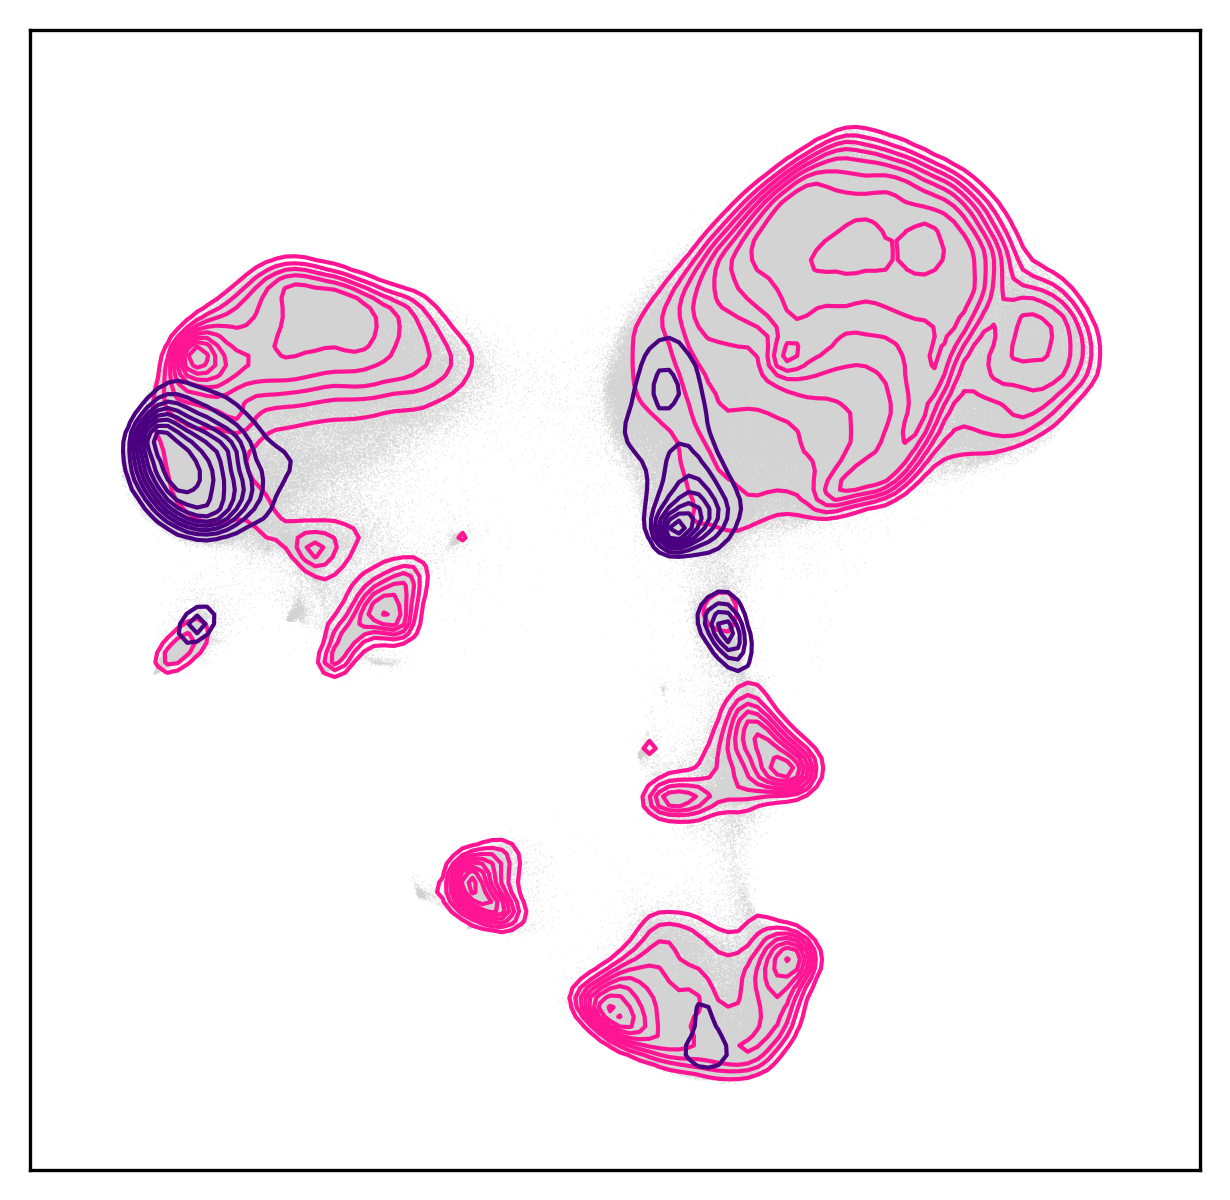

In [ ]:
num_contours = 10

f = plt.figure(figsize = [5,5])
ax = plot_individual_category(
    adata, "X_umap", "cell_type_0", [], [], background_color='white', 
    s = 0.5, figsize_max=5, use_outlines=False, axes_color='white')

xval = adata.obsm['X_umap'][:,0]
yval = adata.obsm['X_umap'][:,1]
plt.scatter(xval, yval, edgecolor = 'None', facecolor = 'lightgray', marker='o', s = 0.1, alpha = 0.5, rasterized = True)

x_, y_, z_grid = make_density_map(adata, cells_in_krasi, "X_umap", num_contours, "deeppink", background_color = None)
x_, y_, z_grid = make_density_map(adata, cells_in_progenitor_niches, "X_umap", num_contours, "indigo", background_color = None)


Plot cells enriched in the vicinity of progenitor-like premalignant cells (purple), and depleted upon KRAS inhibitor (blue) 

<Figure size 400x400 with 0 Axes>

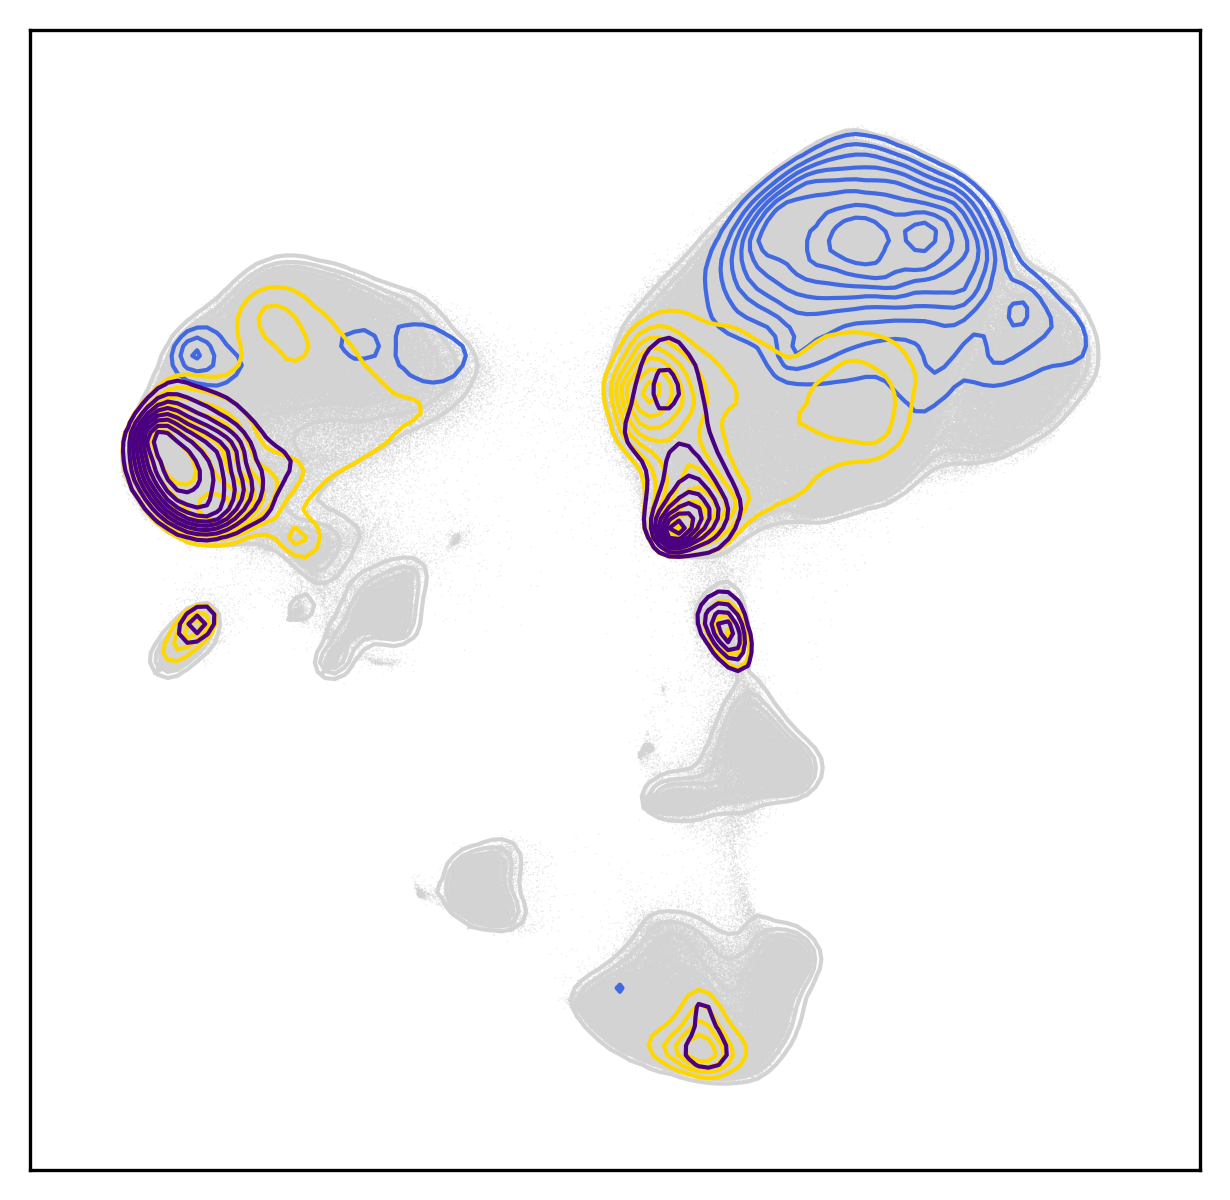

In [ ]:
num_contours = 10

f = plt.figure(figsize = [5,5])
ax = plot_individual_category(
    adata, "X_umap", "cell_type_0", [], [], background_color='white', 
    s = 0.5, figsize_max=5, use_outlines=False, axes_color='white')

xval = adata.obsm['X_umap'][:,0]
yval = adata.obsm['X_umap'][:,1]
plt.scatter(xval, yval, edgecolor = 'None', facecolor = 'lightgray', marker='o', s = 0.1, alpha = 0.5, rasterized = True)

x_, y_, z_grid = make_density_map(adata, cells_in_enriched_neighborhoods, "X_umap", num_contours, "royalblue", background_color = 'lightgray')
x_, y_, z_grid = make_density_map(adata, cells_in_depleted_neighborhoods, "X_umap", num_contours, "gold", background_color = None)
x_, y_, z_grid = make_density_map(adata, cells_in_progenitor_niches, "X_umap", num_contours, "indigo", background_color = None)
